# Sentiment Analysis Using TF-IDF (Term Frequency-Inverse Document Frequency) and Artificial Neural Network (ANN)

## Project Overview

Natural Language Processing (NLP) enables machines to understand, analyze, and extract meaningful information from human language. One of the most fundamental NLP tasks is **Sentiment Analysis**, which aims to determine whether a piece of text expresses a positive or negative opinion.

In this project, I build a complete sentiment analysis pipeline using classical NLP techniques and Machine Learning algorithms. The workflow covers the entire process from raw text preprocessing to feature extraction, model training, evaluation, and experiment documentation.

The primary objective of this project is not only to achieve high predictive performance but also to systematically investigate how different preprocessing techniques, feature engineering strategies, and machine learning models affect sentiment classification performance.

---

## Dataset

Dataset Link: **[IMBD Movie Reviews](https://www.kaggle.com/datasets/mwallerphunware/imbd-movie-reviews-for-binary-sentiment-analysis)**

The dataset consists of movie reviews labeled with their corresponding sentiment:

* Positive
* Negative

The reviews contain real-world natural language, making them suitable for evaluating text preprocessing techniques and machine learning models.

---

## Project Pipeline

The following stages are implemented throughout this project:

### 1. Text Preprocessing

* Contraction expansion
* Lowercasing
* Text cleaning using regular expressions
* Stopword removal with preserved negations
* Lemmatization
* Corpus construction

### 2. Feature Extraction

* Term Frequency-Inverse Document Frequency (TfidfVectorizer)
* N-gram generation
* Vocabulary analysis
* Feature selection using `max_features`
* Rare-word filtering using `min_df`

### 3. Model Training

Different machine learning algorithms are evaluated and compared, including:

* Gaussian Naive Bayes
* Multinomial Naive Bayes
* Bernoulli Naive Bayes
* Logistic Regression
* Support Vector Machines (SVM)
* Decision Trees
* Random Forests

### 4. Model Evaluation

Performance is assessed using multiple metrics:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC Score
* Confusion Matrix
* Cross-Validation Mean Accuracy
* Cross-Validation Standard Deviation

---

## Experimental Approach

Rather than training a single model, this notebook follows an experimentation-driven methodology.

For each model, multiple configurations are tested, including different values for:

* `max_features`
* `min_df`
* N-gram ranges
* Preprocessing strategies

The goal is to identify the most effective configuration while understanding the trade-offs between model complexity, computational cost, and predictive performance.

---

## Key Learning Objectives

Through this project, I aim to:

* Develop a deeper understanding of NLP preprocessing techniques.
* Compare the behavior of different machine learning algorithms on text data.
* Analyze how feature engineering impacts classification performance.
* Build reproducible NLP pipelines suitable for real-world applications.
* Establish strong baselines before moving toward advanced embedding and transformer-based approaches.

---

**Author:** Hazem Mohamed

**Role:** AI Engineer | Machine Learning Engineer | NLP Engineer

**Repository:** [NLP Experimentation Lab](https://github.com/Hazem1695/NLP-Experimentation-Lab)


# **Importing the Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [2]:
tf.__version__

'2.20.0'

# **Data preprocessing**

## Data Cleaning Check Template
This template is designed to quickly assess the quality of any dataset before building machine learning models or performing analysis.

It provides a structured overview of the dataset by checking for common data issues such as:

- Missing values

- Duplicate rows

- Incorrect data types

- Outliers

- Distribution of numerical features

- Categorical feature consistency

**What This Template Does**

- Displays basic dataset information (shape, data types)

- Identifies missing values and duplicates

- Summarizes numerical and categorical features

- Detects potential outliers using the IQR method

- Highlights columns with low unique values for quick inspection

How to Use

1. Load your dataset using Pandas  

2. Call the function:

In [4]:
def data_quality_report(df):

    print("DATA QUALITY REPORT")
    
    # Print a separator line for better readability
    
    print("=" * 50)
    print("BASIC INFO")
    print("=" * 50)
    
    # Show general information about the dataset (columns, data types, non-null values)
    print(df.info())
    
    # Show number of rows and columns
    print("\n" + "=" * 50)
    print("SHAPE OF DATA")
    print("=" * 50)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Check for missing (null) values in each column
    print("\n" + "=" * 50)
    print("MISSING VALUES")
    print("=" * 50)
    missing = df.isnull().sum()
    
    # Display only columns that have missing values
    print(missing[missing > 0])
    
    # Check for duplicate rows
    print("\n" + "=" * 50)
    print("DUPLICATES")
    print("=" * 50)
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    # Display data types of each column
    print("\n" + "=" * 50)
    print("DATA TYPES")
    print("=" * 50)
    print(df.dtypes)
    
    # Summary statistics for numerical columns (mean, std, min, max, etc.)
    print("\n" + "=" * 50)
    print("NUMERICAL SUMMARY")
    print("=" * 50)
    print(df.describe())
    
    # Summary for categorical (object) columns
    print("\n" + "=" * 50)
    print("CATEGORICAL SUMMARY")
    print("=" * 50)
    print(df.describe(include=['object']))
    
    # Show unique values for columns with low number of distinct values
    # Useful for detecting categories, errors, or inconsistencies
    print("\n" + "=" * 50)
    print("UNIQUE VALUES (LOW CARDINALITY)")
    print("=" * 50)
    for col in df.columns:
        if df[col].nunique() < 10:  # Only show columns with few unique values
            print(f"{col}: {df[col].unique()}")
            
    # correlation
    print("\n" + "=" * 50)
    print("CORRELATION MATRIX")
    print("=" * 50)
    print(df.corr(numeric_only=True))
    
    # Detect outliers using the IQR (Interquartile Range) method
    print("\n" + "=" * 50)
    print("OUTLIERS CHECK (IQR METHOD)")
    print("=" * 50)
    
    # Loop through only numerical columns
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        
        # Count rows that fall outside the normal range
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        print(f"{col}: {len(outliers)} outliers")

## **Load dataset**
Apply Data Cleaning Check Template

In [ ]:
dataset = pd.read_csv('MovieReviewTrainingDatabase.csv')
data_quality_report(dataset)

DATA QUALITY REPORT
BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  25000 non-null  object
 1   review     25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB
None

SHAPE OF DATA
Rows: 25000, Columns: 2

MISSING VALUES
Series([], dtype: int64)

DUPLICATES
Duplicate rows: 96

DATA TYPES
sentiment    object
review       object
dtype: object

NUMERICAL SUMMARY
       sentiment                                             review
count      25000                                              25000
unique         2                                              24904
top     Positive  You do realize that you've been watching the E...
freq       12500                                                  3

CATEGORICAL SUMMARY
       sentiment                                             review
count      25000                 

## Duplicate Data Detection

In [6]:
duplicates = dataset[dataset.duplicated(subset=['review'], keep=False)]
duplicates.sort_values('review')

,sentiment,review
21186,Negative,"Back in his youth, the old man had wanted to..."
21877,Negative,"Back in his youth, the old man had wanted to..."
14734,Negative,'Dead Letter Office' is a low-budget film abou...
5519,Negative,'Dead Letter Office' is a low-budget film abou...
7011,Positive,".......Playing Kaddiddlehopper, Col San Fernan..."
...,...,...
2685,Negative,"in this movie, joe pesci slams dunks a basketb..."
22244,Positive,it's amazing that so many people that i know h...
14767,Positive,it's amazing that so many people that i know h...
12462,Negative,this movie begins with an ordinary funeral... ...


## Quantifying Duplicate Review Frequencies

In [7]:
review_counts = dataset['review'].value_counts()
print("Reviews appearing more than once:")
print((review_counts > 1).sum())
print("\nMaximum repetitions:")
print(review_counts.max())

Reviews appearing more than once:
92

Maximum repetitions:
3


## Removing Duplicate Reviews & Resetting Index
> **Note:** This cell drops the repeated rows we identified in the previous steps and cleanly resets the row indices for model training

In [8]:
print("Before:", len(dataset))
dataset = dataset.drop_duplicates()
print("After:", len(dataset))
dataset = dataset.reset_index(drop=True)

Before: 25000
After: 24904


## Library Installation
> **Note:** The `contractions` library is required to automatically expand shortcuts like *don't* to *do not* and *I'm* to *I am* during preprocessing.

In [9]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00


## **Cleaning the texts**

In [10]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

base_stopwords = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never'}
all_stopwords = base_stopwords - negation_words

wnl = WordNetLemmatizer()

corpus = []

for i in range(0, len(dataset)):
    review = dataset['review'][i]
    # Fix contractions
    review = contractions.fix(review)
    # Lowercase
    review = review.lower()
    
    review = re.sub(r'[^a-zA-Z\s]', ' ', review)
    # Split
    words = review.split()
    # Chained Lemmatization (Handles both Verbs 'v' and Nouns 'n')
    review = [wnl.lemmatize(wnl.lemmatize(word, pos='v'), pos='n') for word in words if word not in all_stopwords]
    review = ' '.join(review) 
    corpus.append(review)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## Preprocessing Verification
> **Note:** Pulling the first two rows directly as a memory array to confirm that our lowercasing, stopword stripping, and lemmatization pipeline worked correctly before feeding it into the vectorizer.

In [11]:
# Pull the data directly as a fast memory array
raw_samples = dataset['review'].head(2).values

for i in range(2):
    print(f"=== REVIEW #{i+1} ===")
    print(f"RAW:     {raw_samples[i]}\n") 
    print(f"CLEANED: {corpus[i]}")
    print("-" * 50)

=== REVIEW #1 ===
RAW:     With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.  Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.  The actual feature film bit when it final

# **Encoding Categorical data Using Label Encoding**

In [12]:
from sklearn.preprocessing import LabelEncoder
y = dataset.iloc[:, 0].values
le = LabelEncoder()
y = le.fit_transform(y)

In [13]:
print(y)

[1 1 0 ... 0 0 1]


# Class Balance Check
> **Note:** Using NumPy to verify if our dataset is perfectly balanced between positive and negative reviews before splitting it into training and testing sets.

In [14]:
# This returns the unique classes and how many times they appear
classes, counts = np.unique(y, return_counts=True)
for c, count in zip(classes, counts):
    print(f"Class {c} contains {count}")

Class 0 contains 12432
Class 1 contains 12472


# **Splitting the dataset into the Training set and Test set**

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus, y, test_size = 0.20, random_state = 0)

# **Creating the TF-IDF (Term Frequency-Inverse Document Frequency) model**

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Add ngram_range=(1, 2) so it automatically catches phrases like "not good" or "no clue"
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
X_train = tfidf .fit_transform(X_train).toarray()
X_test = tfidf .transform(X_test).toarray()

In [17]:
print(X_train.shape)        # (n_samples, n_features)
print(X_train.shape[0])     # number of training samples
print(X_train.shape[1])     # number of features (vocabulary size)

(19923, 15000)
19923
15000


In [18]:
print(X_test.shape)        # (n_samples, n_features)
print(X_test.shape[0])     # number of training samples
print(X_test.shape[1])     # number of features (vocabulary size)

(4981, 15000)
4981
15000


# **Building the ANN Model Architecture**

In [19]:
# tf.keras.utils.set_random_seed(42)
input_dim = X_train.shape[1]
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Input(shape =(input_dim,)))
ann.add(tf.keras.layers.Dense(units=128, activation='relu')) # rectifier = relu
ann.add(tf.keras.layers.Dropout(0.4))
ann.add(tf.keras.layers.Dense(units=32, activation='relu'))
ann.add(tf.keras.layers.Dropout(0.2))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

I0000 00:00:1785538447.536420      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Compiling the ANN Model

In [20]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

## Setting Up Callbacks: Early Stopping & Learning Rate Reduction

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)]

## Training the ANN Model 

In [22]:
ann.fit(X_train, y_train, batch_size = 128, validation_split=0.15, epochs = 50, callbacks=callbacks)

Epoch 1/50
 34/133 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6309 - loss: 0.6820

I0000 00:00:1785538457.321956     145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8248 - loss: 0.4434 - val_accuracy: 0.8973 - val_loss: 0.2532 - learning_rate: 0.0010
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9373 - loss: 0.1702 - val_accuracy: 0.8983 - val_loss: 0.2619 - learning_rate: 0.0010
Epoch 3/50
122/133 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9798 - loss: 0.0806
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9750 - loss: 0.0815 - val_accuracy: 0.8916 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9926 - loss: 0.0362 - val_accuracy: 0.8923 - val_loss: 0.3564 - learning_rate: 5.0000e-04
Epoch 5/50
131/133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0228
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9969 - loss: 0.0224 - val_accu

# **Predicting the Test set results**

In [24]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1 1]
 [1 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


# **Evaluating the Model Performance**

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred))

Confusion Matrix:
[[2278  242]
 [ 241 2220]]

Accuracy Score:
0.9030315197751455

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2520
           1       0.90      0.90      0.90      2461

    accuracy                           0.90      4981
   macro avg       0.90      0.90      0.90      4981
weighted avg       0.90      0.90      0.90      4981


ROC-AUC Score:
0.9030202911450372


# **Displaying ANN Model Summary**

In [27]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,772,869 (22.02 MB)

 Trainable params: 1,924,289 (7.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,848,580 (14.68 MB)

# **Visualization**

## Visualizing ANN Architecture Diagram

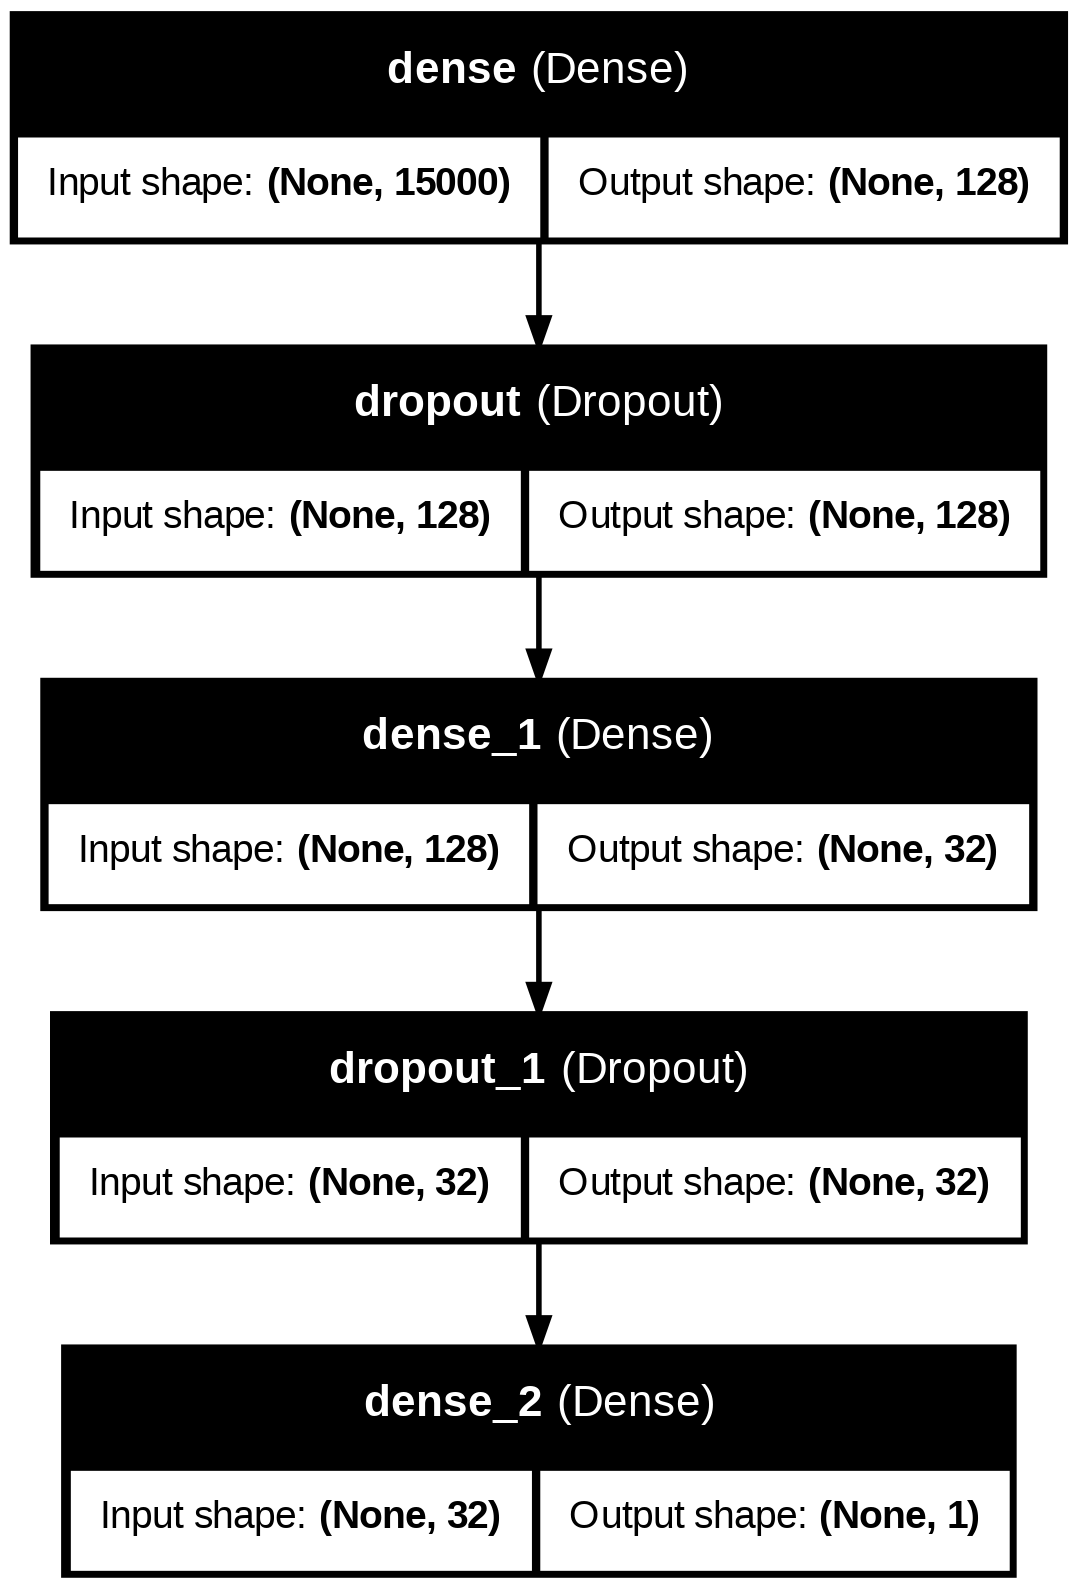

In [28]:
from tensorflow.keras.utils import plot_model

plot_model(
    ann,
    to_file="ann_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

## Visualizing the Confusion Matrix

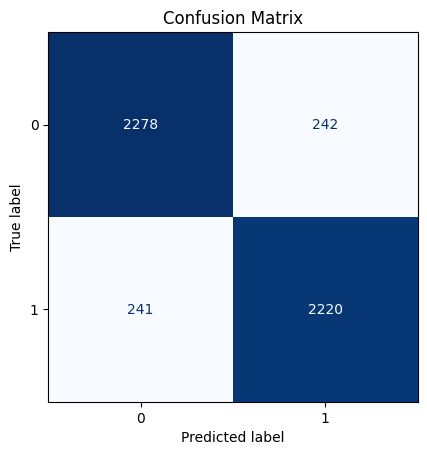

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## Visualizing Prediction Probabilities

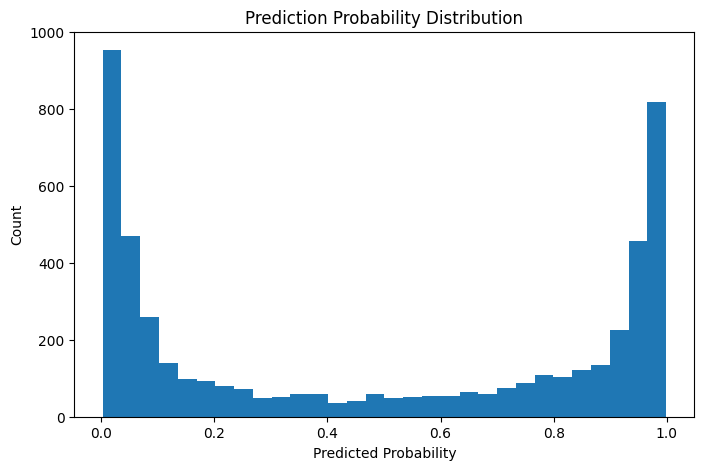

In [31]:
plt.figure(figsize=(8,5))
plt.hist(y_prob, bins=30)

plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")

plt.show()

# Artificial Neural Network (ANN) Performance Analysis for Text Classification (TF-IDF)

# 1. Objective

The objective of this experiment was to evaluate a feedforward **ANN** for binary text classification using features generated by **TfidfVectorizer**, testing both vocabulary size and network architecture (depth, width) as variables, and to compare results against the previously evaluated TF-IDF classifiers as well as the earlier CountVectorizer-based ANN experiment.

Unlike the earlier CountVectorizer ANN experiment, every run here shares an identical training procedure (batch size, validation split, callbacks), which makes the comparisons in this report considerably cleaner to interpret.

The experiment aims to answer the following research questions:

* How does vocabulary size affect ANN performance under TF-IDF weighting?
* Does increasing network width (holding vocabulary fixed) continue to improve results, or is there a point of diminishing or negative returns?
* How does the best TF-IDF ANN compare to the best CountVectorizer ANN, and to the other TF-IDF classifiers evaluated so far?

---

# 2. Experimental Setup

## Dataset

* Final test set: **4,981 documents** (2,520 negative / 2,461 positive).

## Feature Extraction

| Run | Vectorizer Configuration |
| --- | ------------------------- |
| 1   | max_features=5000, ngram_range=(1,2) |
| 2   | max_features=10000, ngram_range=(1,2) |
| 3   | max_features=15000, ngram_range=(1,2) |
| 4   | max_features=20000, min_df=2, ngram_range=(1,2) |
| 5   | max_features=20000, min_df=2, ngram_range=(1,2) *(same vectorizer as Run 4, different architecture)* |

No untuned/no-callback baseline was run in this experiment (unlike the CountVectorizer ANN report's Runs 1-2) — every run here used the same regularized training procedure. No k-fold cross-validation was performed for any run — see Section 10.

---

# 3. Model Architectures Explored

Four distinct architectures were tested across the five runs:

| Run | Architecture | Dropout |
| --- | -------------- | ------- |
| 1   | Dense(6) → Dense(6) → Dense(1) | None |
| 2   | Dense(64) → Dense(16) → Dense(1) | 0.3 / 0.2 |
| 3   | Dense(128) → Dense(32) → Dense(1) | 0.4 / 0.2 |
| 4   | Dense(128) → Dense(32) → Dense(1) | 0.4 / 0.2 *(same as Run 3)* |
| 5   | Dense(256) → Dense(64) → Dense(1) | 0.4 / 0.2 |

Runs 4 and 5 share the exact same vectorizer configuration (20K features, min_df=2), making them the one perfectly isolated architecture comparison in this experiment — see Section 6.

---

# 4. Training Configuration

Every run used an identical training setup:

```python
optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]
batch_size=128, validation_split=0.15, epochs=50 (requested)
```

| Run | Epoch Training Stopped |
| --- | ------------------------ |
| 1   | 7 |
| 2   | 6 |
| 3   | 5 |
| 4   | 5 |
| 5   | 5 |

Training consistently halted well before the requested 50 epochs across all runs, with slightly earlier stopping as vocabulary/architecture size increased. This consistency (unlike the CountVectorizer ANN experiment, where training procedure itself varied between runs) means the results below can be compared more directly against each other.

---

# 5. Experimental Results

| Run | Configuration | Accuracy   | ROC-AUC    |
| --- | -------------- | ---------- | ---------- |
| 1   | 5K, [6,6,1]     | 88.92%     | 0.8894     |
| 2   | 10K, [64,16,1]  | 89.72%     | 0.8972     |
| **3** | **15K, [128,32,1]** | **90.30%** | **0.9030** |
| 4   | 20K, [128,32,1] | 90.06%     | 0.9006     |
| 5   | 20K, [256,64,1] | 89.74%     | 0.8978     |

---

# 6. Performance Analysis

## Effect of Vocabulary Size (Runs 1-4, Architecture Mostly Scaling Alongside)

Accuracy rose from 88.92% (5K) to a peak of 90.30% (15K), then declined slightly to 90.06% at 20K. Since architecture width also increased alongside vocabulary in Runs 1-3 (6→64→128 units), this isn't a fully isolated vocabulary-size effect — but the Run 3→4 comparison (15K→20K, same [128,32] architecture) is clean, and shows the same "peak then mild decline" pattern seen in the tree-based TF-IDF experiments, here centered around 15K rather than 10K.

## Effect of Architecture Width at Fixed Vocabulary (Runs 4 vs. 5 — Isolated Comparison)

This is the cleanest single comparison in the experiment: **identical vectorizer (20K features, min_df=2), identical dropout rates, identical training procedure** — only the layer widths differ.

| Run | Architecture | Trainable Params | Accuracy |
| --- | -------------- | ------------------ | -------- |
| 4   | [128, 32, 1]    | 2,564,289           | **90.06%** |
| 5   | [256, 64, 1]    | 5,136,769           | 89.74%   |

Doubling the network's width — and with it, roughly doubling the trainable parameter count — **did not improve performance and in fact made it slightly worse** (-0.32 points). This is a genuine "bigger is not automatically better" result: the extra capacity likely wasn't needed for this feature representation, and may have made the model marginally more prone to overfitting even with dropout active, or simply added optimization noise without a compensating benefit. This is a useful data point for future architecture decisions on this dataset — the 128→32 configuration appears to be closer to the right capacity than 256→64.

## Best Overall Result

Run 3 (15K features, [128,32,1] architecture) is the best result of the entire experiment at 90.30% accuracy — notably, this beats the CountVectorizer ANN's best result (90.02% at 30K features) while using **half the vocabulary size**.

---

# 7. Precision and Recall Analysis

| Run | Class | Precision | Recall | F1-score |
| --- | ----- | --------- | ------ | -------- |
| 1   | 0     | 0.90      | 0.87   | 0.89     |
| 1   | 1     | 0.87      | 0.91   | 0.89     |
| 2   | 0     | 0.90      | 0.89   | 0.90     |
| 2   | 1     | 0.89      | 0.90   | 0.90     |
| **3** | **0** | **0.90**  | **0.90** | **0.90** |
| **3** | **1** | **0.90**  | **0.90** | **0.90** |
| 4   | 0     | 0.90      | 0.90   | 0.90     |
| 4   | 1     | 0.90      | 0.90   | 0.90     |
| 5   | 0     | 0.93      | 0.86   | 0.89     |
| 5   | 1     | 0.87      | 0.93   | 0.90     |

The best model (Run 3) and Run 4 both achieve near-perfectly balanced precision/recall across classes — a 0-point gap. Run 5, despite its much larger network, shows the *most* imbalanced precision/recall of any run in this experiment (7-point gaps), reinforcing the Section 6 finding that the wider architecture is a step backward, not just in accuracy but in class balance too.

---

# 8. ROC-AUC Analysis

| Run | Configuration | ROC-AUC |
| --- | -------------- | ------- |
| 1   | 5K, [6,6,1]     | 0.8894  |
| 2   | 10K, [64,16,1]  | 0.8972  |
| **3** | **15K, [128,32,1]** | **0.9030** |
| 4   | 20K, [128,32,1] | 0.9006  |
| 5   | 20K, [256,64,1] | 0.8978  |

ROC-AUC tracks accuracy closely, including the Run 4→5 decline.

---

# 9. Model Complexity Analysis

| Run | Vocab Size | Architecture | Trainable Params | Accuracy |
| --- | ---------- | -------------- | ------------------ | -------- |
| 1   | 5,000      | [6,6,1]         | 30,055              | 88.92%   |
| 2   | 10,000     | [64,16,1]       | 641,121             | 89.72%   |
| **3** | **15,000** | **[128,32,1]** | **1,924,289**       | **90.30%** |
| 4   | 20,000     | [128,32,1]      | 2,564,289           | 90.06%   |
| 5   | 20,000     | [256,64,1]      | **5,136,769**       | 89.74%   |

As in the CountVectorizer ANN experiment, **Total params ≈ 3 × Trainable params** holds consistently across every run here too (Adam's optimizer state overhead). Run 5 is the most expensive model of the entire series — roughly 2x the parameters of the best model (Run 3) — for a worse result, making it strictly dominated on both accuracy and cost.

---

# 10. Best Model Configuration

```python
TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2)
)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]
model.fit(X_train, y_train, batch_size=128, validation_split=0.15, epochs=50, callbacks=callbacks)
```

Performance:

* Accuracy = **90.30%**
* Precision (Class 0 / 1) = **0.90 / 0.90**
* Recall (Class 0 / 1) = **0.90 / 0.90**
* ROC-AUC = **0.9030**
* Cross-Validation: not performed (see Section 10)

---

# 11. Comparison with Previously Evaluated Models (TF-IDF)

| Model                    | Best Accuracy | ROC-AUC    |
| -------------------------- | -------------- | ---------- |
| **ANN**                     | **90.30%**     | **0.9030** |
| LinearSVC                   | 90.18%         | 0.9020     |
| Logistic Regression         | 89.46%         | 0.8948     |
| Naive Bayes (Multinomial)   | 88.13%         | 0.8815     |
| XGBoost                     | 87.13%         | 0.8714     |
| Random Forest               | 85.75%         | 0.8579     |
| K-Nearest Neighbors         | 80.41%         | 0.8047     |
| Decision Tree               | 74.94%         | 0.7504     |

**This is the first model in the entire series (either vectorizer) to overtake LinearSVC**, by a narrow 0.12-point margin. Given that ANN has no CV-based stability estimate while LinearSVC does, this should be read as "essentially tied for first, pending ANN cross-validation" rather than a decisive win — but it's a notable milestone regardless.

---

# 12. Cross-Vectorizer Comparison: ANN on CountVectorizer vs. TF-IDF

*(New section — directly comparing this experiment to the earlier CountVectorizer ANN report, since both use the same model family.)*

| Vectorizer | Best Config | Accuracy | ROC-AUC | Trainable Params |
| ----------- | ------------ | -------- | ------- | ------------------ |
| CountVectorizer | 30K features, [128,32,1] | 90.02% | 0.9006 | ~3,844,289 (estimated) |
| **TF-IDF**       | **15K features, [128,32,1]** | **90.30%** | **0.9030** | **1,924,289** |

TF-IDF reaches a slightly higher accuracy while using **half the vocabulary size and roughly half the trainable parameters** of the best CountVectorizer result. This is consistent with TF-IDF's term-weighting giving the network a "head start" — down-weighting common, less-informative words lets a smaller network extract comparable or better signal than a larger network has to work to extract from raw counts. This mirrors a similar (though smaller) advantage seen in the Decision Tree TF-IDF vs. BoW comparison, where TF-IDF's best result also modestly exceeded BoW's.

---

# 13. Discussion

Three findings define this experiment. First, the TF-IDF ANN's best result (90.30%) is the strongest of the entire series to date, edging out LinearSVC and doing so with meaningfully less vocabulary than the CountVectorizer ANN needed to reach a similar level. Second, the Run 4 vs. 5 comparison is a clean, well-controlled demonstration that increasing network width isn't a free win — it can actively hurt performance while adding substantial computational cost, which is a useful practical lesson for any further architecture tuning on this dataset. Third, this experiment's consistent training procedure across all runs (unlike the CountVectorizer version) makes its internal comparisons meaningfully more trustworthy.

The lack of cross-validation remains the most important open item before the 90.30% figure is treated as definitively ahead of LinearSVC — with only a 0.12-point gap and no CV-based confidence interval for the ANN, this ranking could plausibly flip under a different train/test split.

---

# 14. Final Conclusion

This experiment evaluated a feedforward ANN across four architectures and five TF-IDF configurations, using a consistent training procedure throughout. The best model used **TfidfVectorizer with 15,000 features and bigrams**, paired with a **128→32→1 dense network with dropout (0.4/0.2)**, achieving **90.30% accuracy** and **0.9030 ROC-AUC** — the best result of the entire series so far, narrowly ahead of LinearSVC (90.18%) and ahead of the CountVectorizer ANN's best (90.02%) while using half the vocabulary and half the trainable parameters.

The clearest actionable finding is the Run 4 vs. 5 comparison: doubling network width at a fixed vocabulary size made results worse, not better — a useful boundary to know before investing more compute in wider architectures on this dataset.